# CZSL 零样本推理示例

本笔记展示如何使用训练好的 CLIP-CZSL 模型进行雷达干扰信号的零样本组合识别。

主要功能：
1. 加载预训练的 CZSL 模型
2. 加载 STFT 数据并进行预处理
3. 构建文本描述模板
4. 执行零样本预测
5. 可视化预测结果

## 1. 环境准备

In [5]:
import os
import sys
import yaml
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

# 添加项目路径
sys.path.insert(0, str(Path.cwd().parent))

from multi.model import create_czsl_model
from multi.data import create_czsl_dataloaders
from multi.text_templates import get_inference_description,get_imagenet_descriptions
import clip

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

PyTorch version: 2.9.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2060


## 2. 加载模型

In [2]:
# 配置文件路径
config_path = "../multi/config.yaml"
checkpoint_path = "../checkpoints/czsl_best_model.pt"

# 加载配置
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# 获取类别名称
class_names = [cls['name'] for cls in config.get('jamming_classes', [])]
print(f"干扰类型数量: {len(class_names)}")
print(f"干扰类型: {class_names}")

干扰类型数量: 14
干扰类型: ['DFTJ', 'ISRJ', 'AJ', 'BJ', 'SJ', 'NCJ', 'NPJ', 'SMSPJ', 'C&IJ', 'NFMJ', 'NPMJ', 'NAMJ', 'CSJ', 'PJ']


In [3]:
# 创建模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_czsl_model(config, device=str(device))

# 加载训练好的权重
if os.path.exists(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)
    print(f"Loaded checkpoint from {checkpoint_path}")
else:
    print(f"Warning: Checkpoint not found at {checkpoint_path}")
    print("Using pretrained CLIP weights (zero-shot without fine-tuning)")

model.eval()
print("Model loaded successfully!")

Loaded checkpoint from ../checkpoints/czsl_best_model.pt
Model loaded successfully!


## 3. 文本特征缓存

CLIP 的零样本分类需要预先计算所有类别的文本特征。我们使用与训练一致的模板格式。

In [6]:
# 显示推理用的文本模板
print("="*60)
print("文本模板（推理用）")
print("="*60)
for cls_name in class_names:
    desc = get_imagenet_descriptions([cls_name])
    print(f"  {cls_name}: \"{desc}\"")

# 组合干扰模板示例
print("\n组合干扰模板示例:")
for combo in [['DFTJ', 'ISRJ'], ['AJ', 'BJ'], ['CSJ', 'NCJ']]:
    desc = get_imagenet_descriptions(combo)
    print(f"  {'+'.join(combo)}: \"{desc}\"")

文本模板（推理用）
  DFTJ: "["a bad photo of a radar signal with Type['DFTJ'].", "a photo of many radar signal with Type['DFTJ'].", "a sculpture of a radar signal with Type['DFTJ'].", "a photo of the hard to see radar signal with Type['DFTJ'].", "a low resolution photo of the radar signal with Type['DFTJ'].", "a rendering of a radar signal with Type['DFTJ'].", "graffiti of a radar signal with Type['DFTJ'].", "a bad photo of the radar signal with Type['DFTJ'].", "a cropped photo of the radar signal with Type['DFTJ'].", "a tattoo of a radar signal with Type['DFTJ'].", "the embroidered radar signal with Type['DFTJ'].", "a photo of a hard to see radar signal with Type['DFTJ'].", "a bright photo of a radar signal with Type['DFTJ'].", "a photo of a clean radar signal with Type['DFTJ'].", "a photo of a dirty radar signal with Type['DFTJ'].", "a dark photo of the radar signal with Type['DFTJ'].", "a drawing of a radar signal with Type['DFTJ'].", "a photo of my radar signal with Type['DFTJ'].", "the pla

In [7]:
# 缓存文本特征
model.cache_text_features(max_combination_size=1, include_single=True)
print(f"\n缓存了 {len(model._combination_names)} 个文本特征")
print(f"类别数: {len(class_names)}, 组合数: {len(model._combination_names) - len(class_names)}")

Cached 14 text features:
  - Single classes: 14
  - Combinations (all pairs): 0

缓存了 14 个文本特征
类别数: 14, 组合数: 0


## 4. 加载测试数据

In [8]:
# 创建数据加载器
train_loader, val_loader, test_loader, num_classes = create_czsl_dataloaders(config)

print(f"训练集: {len(train_loader.dataset)} 样本")
print(f"验证集: {len(val_loader.dataset)} 样本")
print(f"测试集: {len(test_loader.dataset)} 样本")

Loaded train data from JNR_+0: 1120 samples
Loaded train data from JNR_+5: 1120 samples
Loaded train data from JNR_+10: 1120 samples
Loaded train data from JNR_+15: 1120 samples
Loaded train data from JNR_+20: 1120 samples
Loaded val data from JNR_+0: 280 samples
Loaded val data from JNR_+5: 280 samples
Loaded val data from JNR_+10: 280 samples
Loaded val data from JNR_+15: 280 samples
Loaded val data from JNR_+20: 280 samples
Loaded test data from JNR_+0: 1400 samples
Loaded test data from JNR_+5: 1400 samples
Loaded test data from JNR_+10: 1400 samples
Loaded test data from JNR_+15: 1400 samples
Loaded test data from JNR_+20: 1400 samples
训练集: 5600 样本
验证集: 1400 样本
测试集: 7000 样本


In [9]:
# 获取一个批次的数据进行演示
data_iter = iter(test_loader)
batch = next(data_iter)

# 解包数据: (stft_images, time_signals, text_tokens, labels, texts, metas)
stft_images, time_signals, text_tokens, labels, texts, metas = batch

print(f"批次大小: {stft_images.shape[0]}")
print(f"STFT 图像形状: {stft_images.shape}")
print(f"标签形状: {labels.shape}")

AttributeError: Caught AttributeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\Castle\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\Users\Castle\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "d:\VScode\CLIP\multi\data.py", line 63, in collate_fn
    text_tokens = clip.tokenize(texts, truncate=True)
  File "d:\VScode\CLIP\clip\clip.py", line 230, in tokenize
    all_tokens = [[sot_token] + _tokenizer.encode(text) + [eot_token] for text in texts]
  File "d:\VScode\CLIP\clip\clip.py", line 230, in <listcomp>
    all_tokens = [[sot_token] + _tokenizer.encode(text) + [eot_token] for text in texts]
  File "d:\VScode\CLIP\clip\simple_tokenizer.py", line 123, in encode
    text = whitespac

## 5. 可视化 STFT 图像

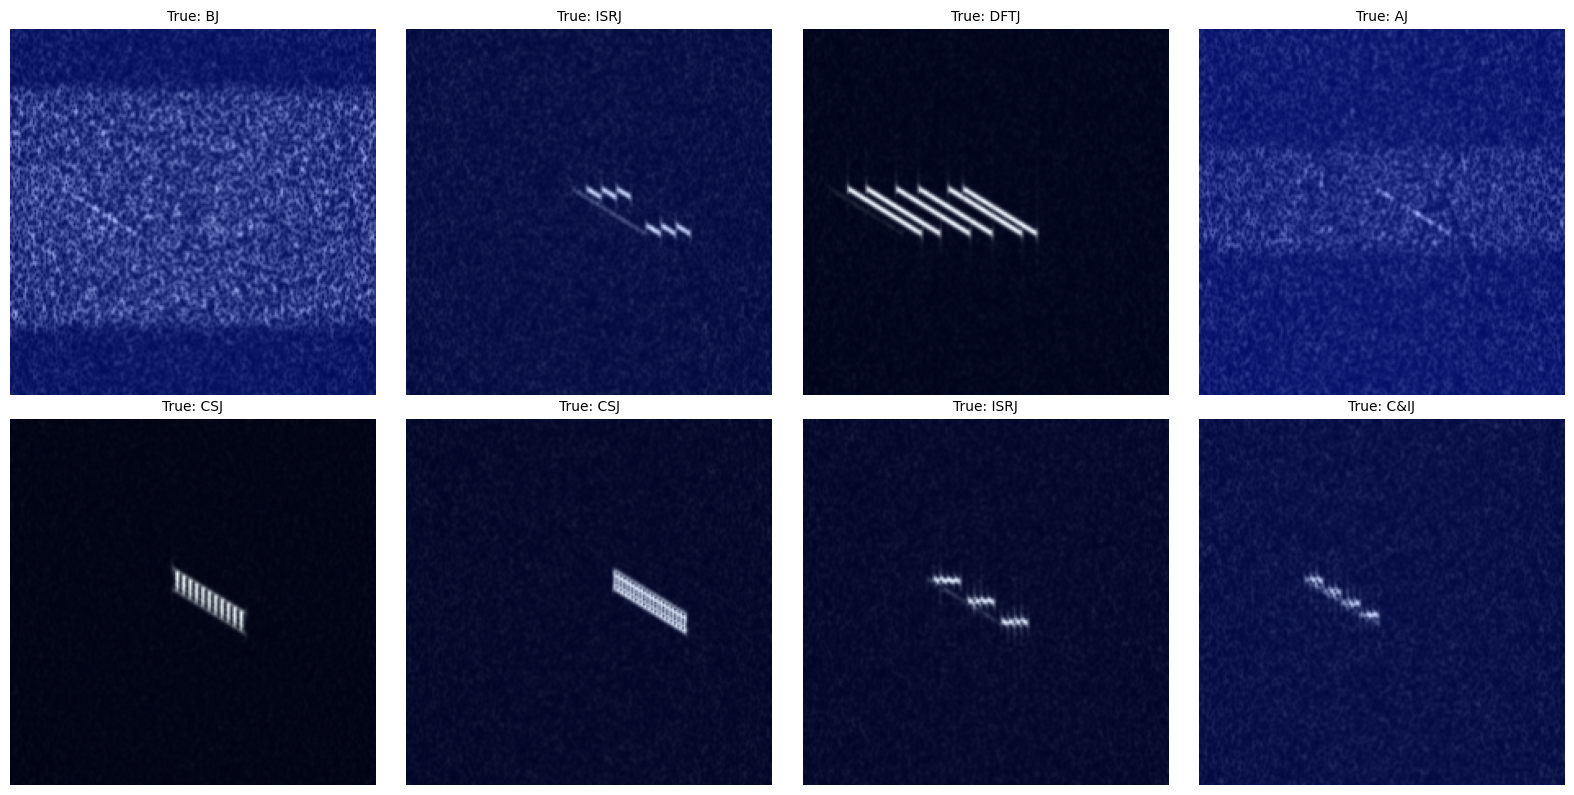

In [14]:
# 可视化几个样本
def visualize_stft_samples(images, labels, texts, class_names, num_samples=8):
    """可视化 STFT 图像样本"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        
        # STFT 图像 (3通道: 实部, 虚部, 幅度)
        img = images[i].permute(1, 2, 0).numpy()
        
        # 归一化到 [0, 1] 用于显示
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        ax.imshow(img)
        
        # 获取真实标签
        true_indices = torch.where(labels[i] == 1)[0].tolist()
        true_names = [class_names[idx] for idx in true_indices]
        
        ax.set_title(f"True: {', '.join(true_names)}", fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_stft_samples(stft_images, labels, texts, class_names)

## 6. 零样本预测

In [15]:
def zero_shot_predict(model, images, class_names, device, top_k=3):
    """
    零样本预测函数
    
    Args:
        model: CZSL 模型
        images: 图像张量 [batch, 3, H, W]
        class_names: 类别名称列表
        device: 计算设备
        top_k: 选择 top-k 个类别
    
    Returns:
        preds: 预测结果 [batch, num_classes]
        probs: 概率分布 [batch, num_classes]
    """
    model.eval()
    
    with torch.no_grad():
        images = images.to(device)
        
        # 编码图像
        image_features = model.encode_image(images)
        image_features = F.normalize(image_features, dim=-1)
        
        # 获取缓存的文本特征
        text_features = model.get_cached_text_features()
        
        # 计算相似度
        logit_scale = model.model.logit_scale.exp()
        logits = logit_scale * (image_features @ text_features.T)
        
        # Softmax 获取概率
        probs = F.softmax(logits, dim=-1)
        
        # 多标签预测策略：选择 top-k 中概率超过阈值的类别
        num_classes = len(class_names)
        threshold = 1.0 / num_classes  # 均匀分布阈值
        
        topk_values, topk_indices = torch.topk(probs, k=top_k, dim=-1)
        
        preds = torch.zeros(images.shape[0], num_classes, device=device)
        for b in range(images.shape[0]):
            for j, idx in enumerate(topk_indices[b]):
                if topk_values[b, j] > threshold:
                    preds[b, idx] = 1.0
    
    return preds.cpu(), probs.cpu()

# 执行预测
preds, probs = zero_shot_predict(model, stft_images, class_names, device)

print(f"预测结果形状: {preds.shape}")
print(f"概率分布形状: {probs.shape}")

Cached 105 text features:
  - Single classes: 14
  - Combinations (all pairs): 91
预测结果形状: torch.Size([16, 14])
概率分布形状: torch.Size([16, 14])


## 7. 分析预测结果

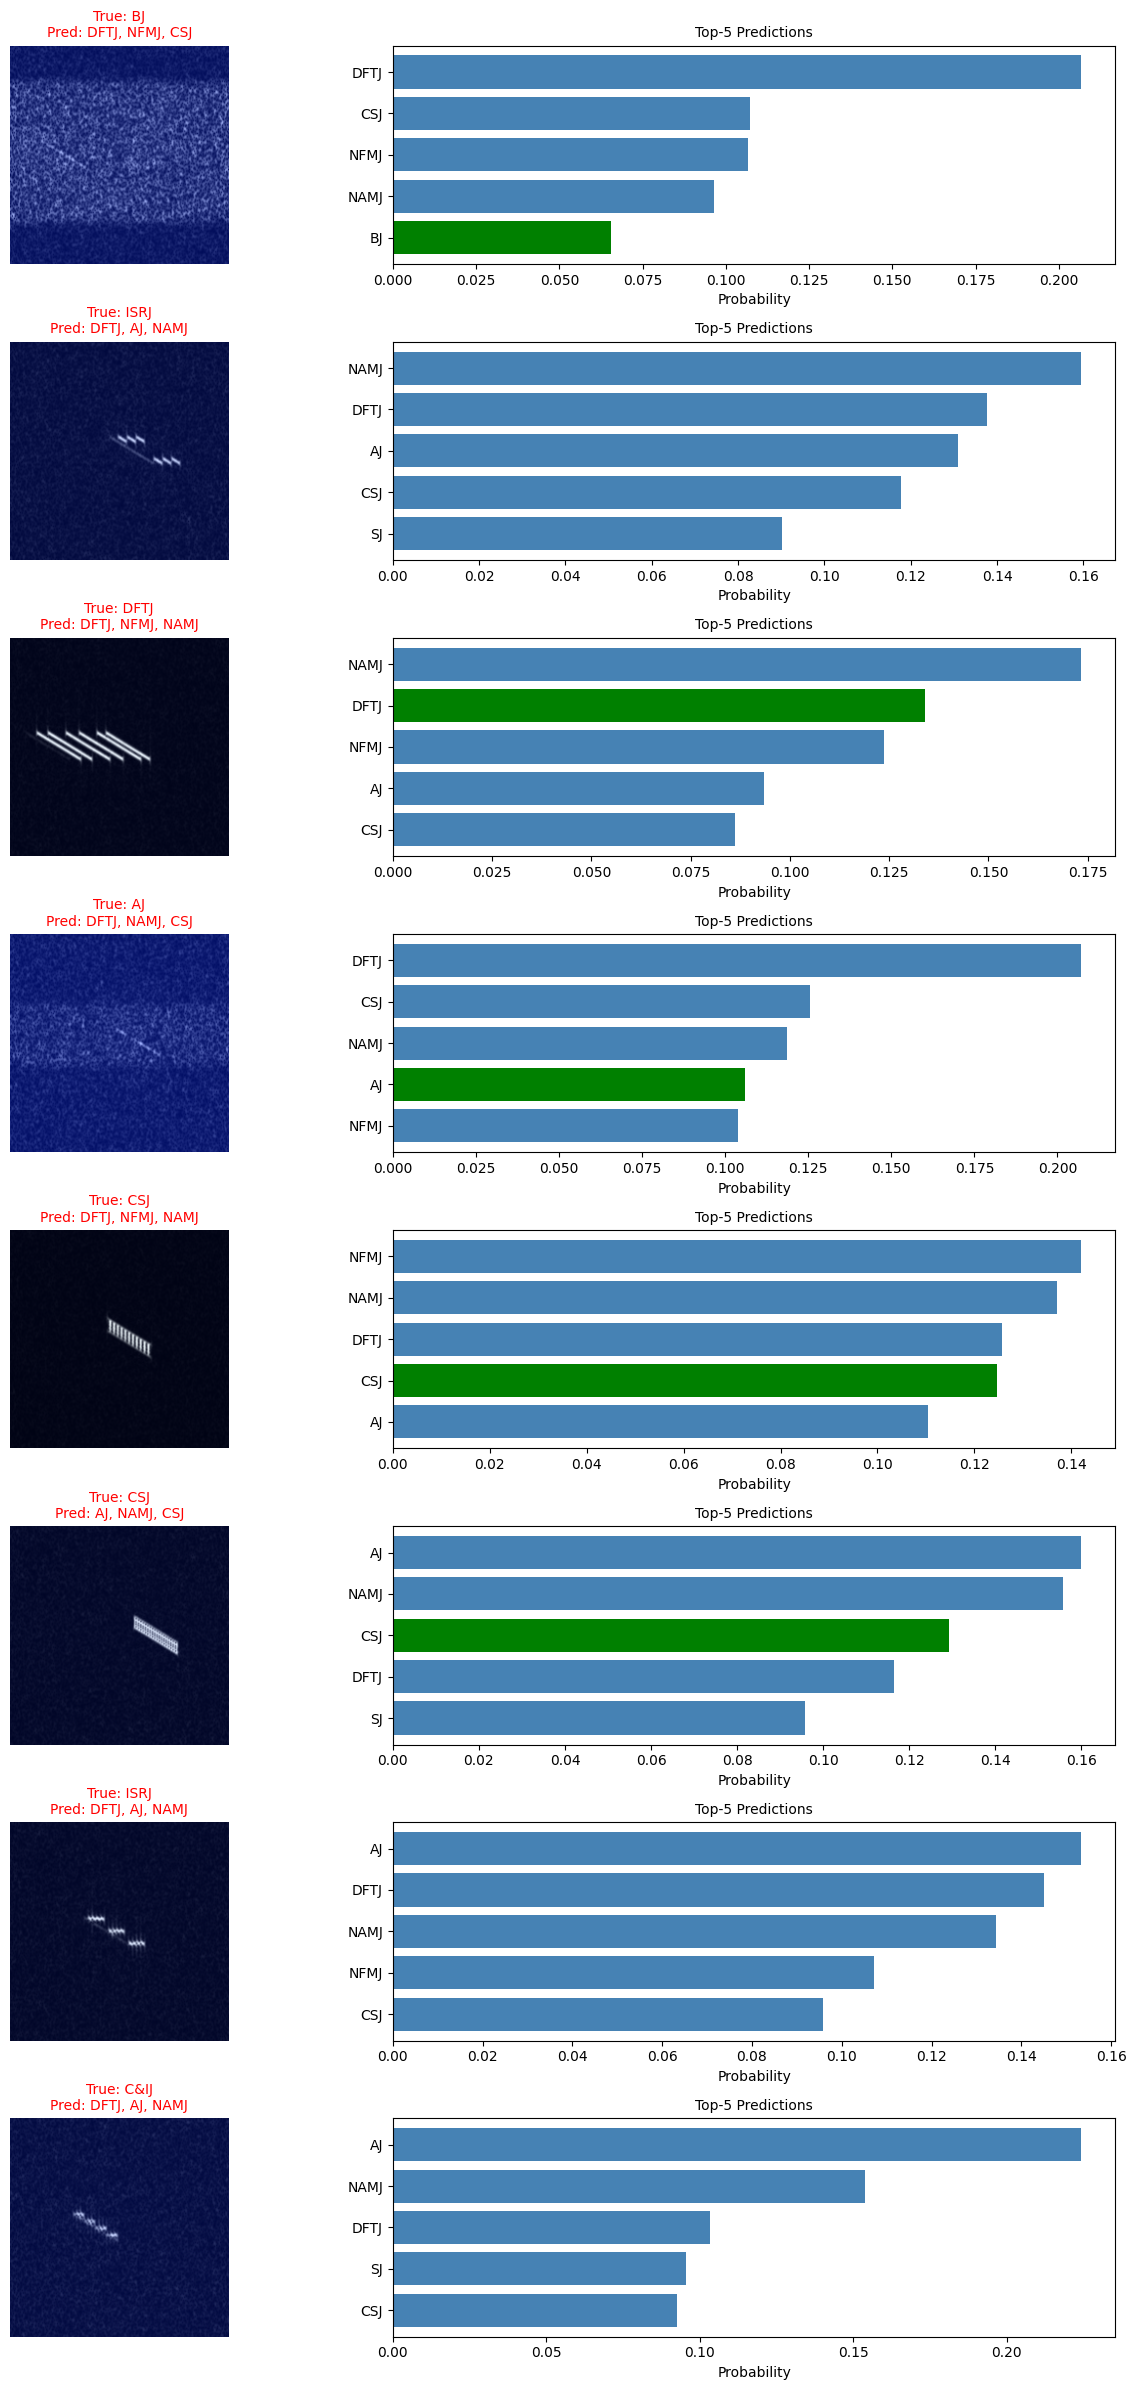

In [16]:
def analyze_predictions(images, labels, preds, probs, texts, class_names, num_samples=8):
    """
    分析并可视化预测结果
    """
    batch_size = min(num_samples, len(images))
    
    fig, axes = plt.subplots(batch_size, 2, figsize=(14, 3 * batch_size))
    
    for i in range(batch_size):
        # 左侧：STFT 图像
        ax_img = axes[i, 0] if batch_size > 1 else axes[0]
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax_img.imshow(img)
        ax_img.axis('off')
        
        # 获取标签
        true_indices = torch.where(labels[i] == 1)[0].tolist()
        pred_indices = torch.where(preds[i] == 1)[0].tolist()
        true_names = [class_names[idx] for idx in true_indices]
        pred_names = [class_names[idx] for idx in pred_indices]
        
        is_correct = set(true_indices) == set(pred_indices)
        color = 'green' if is_correct else 'red'
        
        ax_img.set_title(f"True: {', '.join(true_names)}\nPred: {', '.join(pred_names)}", 
                        fontsize=10, color=color)
        
        # 右侧：概率分布条形图
        ax_bar = axes[i, 1] if batch_size > 1 else axes[1]
        
        # 获取 top-5 概率
        top5_probs, top5_indices = torch.topk(probs[i], k=5)
        top5_names = [class_names[idx] for idx in top5_indices]
        
        y_pos = np.arange(5)
        colors = ['green' if idx.item() in true_indices else 'steelblue' for idx in top5_indices]
        
        ax_bar.barh(y_pos, top5_probs.numpy(), color=colors)
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(top5_names)
        ax_bar.invert_yaxis()
        ax_bar.set_xlabel('Probability')
        ax_bar.set_title('Top-5 Predictions', fontsize=10)
    
    plt.tight_layout()
    plt.show()

analyze_predictions(stft_images, labels, preds, probs, texts, class_names)

## 8. 计算整体准确率

In [ ]:
def calculate_metrics(labels, preds):
    """
    计算评估指标
    """
    # 组合准确率（完全匹配）
    correct = 0
    for i in range(len(labels)):
        true_set = set(torch.where(labels[i] == 1)[0].tolist())
        pred_set = set(torch.where(preds[i] == 1)[0].tolist())
        if true_set == pred_set:
            correct += 1
    
    combination_acc = correct / len(labels)
    
    # 每个类别的准确率
    num_classes = labels.shape[1]
    per_class_acc = []
    for c in range(num_classes):
        true_pos = ((labels[:, c] == 1) & (preds[:, c] == 1)).sum().item()
        false_neg = ((labels[:, c] == 1) & (preds[:, c] == 0)).sum().item()
        false_pos = ((labels[:, c] == 0) & (preds[:, c] == 1)).sum().item()
        
        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        per_class_acc.append({'precision': precision, 'recall': recall, 'f1': f1})
    
    return combination_acc, per_class_acc

# 计算指标
comb_acc, per_class = calculate_metrics(labels, preds)

print("="*60)
print(f"组合准确率 (完全匹配): {comb_acc:.4f}")
print("="*60)
print("\n每个类别的指标:")
print(f"{'Class':<10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*42)
for i, name in enumerate(class_names):
    print(f"{name:<10} {per_class[i]['precision']:>10.4f} {per_class[i]['recall']:>10.4f} {per_class[i]['f1']:>10.4f}")

## 9. 混淆矩阵分析

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# 计算多标签混淆矩阵
cm = multilabel_confusion_matrix(labels.numpy(), preds.numpy())

# 可视化几个类别的混淆矩阵
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (ax, name) in enumerate(zip(axes.flat, class_names[:8])):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm[i], display_labels=['Not ' + name, name])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.suptitle('Per-Class Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

## 10. 特征可视化 (t-SNE)

In [ ]:
from sklearn.manifold import TSNE

# 提取图像特征
with torch.no_grad():
    images_device = stft_images.to(device)
    features = model.encode_image(images_device)
    features = F.normalize(features, dim=-1).cpu().numpy()

# t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(features) - 1))
features_2d = tsne.fit_transform(features)

# 可视化
plt.figure(figsize=(12, 10))

# 获取每个样本的主要类别（第一个正标签）
primary_labels = []
for i in range(len(labels)):
    true_indices = torch.where(labels[i] == 1)[0].tolist()
    if true_indices:
        primary_labels.append(true_indices[0])
    else:
        primary_labels.append(-1)

primary_labels = np.array(primary_labels)

# 为每个类别绘制散点
for c in range(len(class_names)):
    mask = primary_labels == c
    if mask.sum() > 0:
        plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                   label=class_names[c], alpha=0.7, s=50)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('t-SNE Visualization of Image Features')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()

## 11. 批量评估整个测试集

In [ ]:
from tqdm import tqdm

def evaluate_dataset(model, data_loader, class_names, device):
    """
    评估整个数据集
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            images = batch[0].to(device)
            labels = batch[3]
            
            # 编码图像
            image_features = model.encode_image(images)
            image_features = F.normalize(image_features, dim=-1)
            
            # 获取文本特征
            text_features = model.get_cached_text_features()
            
            # 计算相似度
            logit_scale = model.model.logit_scale.exp()
            logits = logit_scale * (image_features @ text_features.T)
            probs = F.softmax(logits, dim=-1)
            
            # 预测
            num_classes = len(class_names)
            threshold = 1.0 / num_classes
            top_k = 3
            topk_values, topk_indices = torch.topk(probs, k=top_k, dim=-1)
            
            preds = torch.zeros(images.shape[0], num_classes, device=device)
            for b in range(images.shape[0]):
                for j, idx in enumerate(topk_indices[b]):
                    if topk_values[b, j] > threshold:
                        preds[b, idx] = 1.0
            
            all_labels.append(labels)
            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())
    
    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_probs = torch.cat(all_probs).numpy()
    
    return all_labels, all_preds, all_probs

# 评估测试集
print("Evaluating on test set...")
test_labels, test_preds, test_probs = evaluate_dataset(model, test_loader, class_names, device)

# 计算整体准确率
comb_acc, per_class = calculate_metrics(torch.tensor(test_labels), torch.tensor(test_preds))

print("\n" + "="*60)
print(f"测试集组合准确率: {comb_acc:.4f}")
print(f"总样本数: {len(test_labels)}")
print("="*60)

## 12. 总结

本笔记展示了 CLIP-CZSL 模型的零样本推理流程：

1. **模型加载**: 加载预训练的 CLIP 模型和微调后的权重
2. **文本模板**: 使用与训练一致的模板格式缓存文本特征
3. **图像编码**: 提取 STFT 图像的视觉特征
4. **零样本预测**: 通过图像-文本相似度进行分类
5. **多标签策略**: 使用 softmax + top-k + 阈值策略

### 关键参数
- `threshold = 1/num_classes`: 均匀分布阈值
- `top_k = 3`: 最多选择3个类别（支持单干扰和双干扰组合）